### Context

DRS bank is facing challenging times. Their NPAs (Non-Performing Assets) have been on a rise recently and a large part of these are due to the loans given to individual customers(borrowers). The Chief Risk Officer of the bank decides to put in a scientifically robust framework for approval of loans to individual customers to minimize the risk of loans converting into NPAs and initiates a project for the data science team at the bank. You, as a senior member of the team, are assigned this project.

### Objective
To identify the criteria to approve loans for an individual customer such that the likelihood of the loan delinquency is minimized

### Key questions to be answered
What are the factors that drive the behavior of loan delinquency?

### Data Description
* ID: Customer ID
* isDelinquent : indicates whether the customer is delinquent or not (1 => Yes, 0 => No)
* term: Loan term in months
* gender: Gender of the borrower
* age: Age of the borrower
* purpose: Purpose of Loan
* home_ownership: Status of borrower's home
* FICO: FICO (i.e. the bureau score) of the borrower

### Domain Information 
Transactor – A person who pays his due amount balance full and on time.

Revolver – A person who pays the minimum due amount but keeps revolving his balance and does not pay the full amount.

Delinquent - Delinquency means that you are behind on payments, a person who fails to pay even the minimum due amount.

Defaulter – Once you are delinquent for a certain period your lender will declare you to be in the default stage.

Risk Analytics – A wide domain in the financial and banking industry, basically analyzing the risk of the customer.


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    train_test_split,
    StratifiedKFold,
    cross_val_score)
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    confusion_matrix)

In [5]:
data = pd.read_csv('Loan_Delinquent_Dataset.csv')
data.shape

(11548, 8)

In [6]:
loan = data.copy()

In [7]:
loan.head(3)

,ID,isDelinquent,term,gender,purpose,home_ownership,age,FICO
0,1,1,36 months,Female,House,Mortgage,>25,300-500
1,2,0,36 months,Female,House,Rent,20-25,>500
2,3,1,36 months,Female,House,Rent,>25,300-500


In [8]:
loan.tail()

,ID,isDelinquent,term,gender,purpose,home_ownership,age,FICO
11543,11544,0,60 months,Male,other,Mortgage,>25,300-500
11544,11545,1,36 months,Male,House,Rent,20-25,300-500
11545,11546,0,36 months,Female,Personal,Mortgage,20-25,>500
11546,11547,1,36 months,Female,House,Rent,20-25,300-500
11547,11548,1,36 months,Male,Personal,Mortgage,20-25,300-500


In [10]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11548 entries, 0 to 11547
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              11548 non-null  int64 
 1   isDelinquent    11548 non-null  int64 
 2   term            11548 non-null  object
 3   gender          11548 non-null  object
 4   purpose         11548 non-null  object
 5   home_ownership  11548 non-null  object
 6   age             11548 non-null  object
 7   FICO            11548 non-null  object
dtypes: int64(2), object(6)
memory usage: 721.9+ KB


In [11]:
# change fields to category
cat_cols = ['term','gender','purpose','home_ownership',
            'age','FICO','isDelinquent']
for col in cat_cols:
    loan[col] = loan[col].astype('category')

In [12]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11548 entries, 0 to 11547
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID              11548 non-null  int64   
 1   isDelinquent    11548 non-null  category
 2   term            11548 non-null  category
 3   gender          11548 non-null  category
 4   purpose         11548 non-null  category
 5   home_ownership  11548 non-null  category
 6   age             11548 non-null  category
 7   FICO            11548 non-null  category
dtypes: category(7), int64(1)
memory usage: 170.4 KB


In [13]:
# check for duplicated data
loan.duplicated().sum()

0

In [15]:
# check for missing values
loan.isnull().sum()

ID                0
isDelinquent      0
term              0
gender            0
purpose           0
home_ownership    0
age               0
FICO              0
dtype: int64

In [18]:
loan.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,11548.0,NaN,NaN,NaN,5774.5,3333.764789,1.0,2887.75,5774.5,8661.25,11548.0
isDelinquent,11548.0,2.0,1.0,7721.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
term,11548,2,36 months,10589,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,11548,2,Male,6555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,11548,7,House,6892,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_ownership,11548,3,Mortgage,5461,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,11548,2,20-25,5888,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FICO,11548,2,300-500,6370,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Pre-Processing

In [19]:
loan['ID'].nunique()

11548

In [22]:
# drop ID field
loan.drop(['ID'], axis=1, inplace=True)

In [24]:
loan['purpose'].unique()

['House', 'Car', 'Other', 'Personal', 'Wedding', 'Medical', 'other']
Categories (7, object): ['Car', 'House', 'Medical', 'Other', 'Personal', 'Wedding', 'other']

In [25]:
# merge 'Other' and 'other'
loan['purpose'].replace('other', 'Other', inplace=True)

In [26]:
loan['purpose'].unique()

['House', 'Car', 'Other', 'Personal', 'Wedding', 'Medical']
Categories (6, object): ['Car', 'House', 'Medical', 'Other', 'Personal', 'Wedding']

## EDA

### Univariate analysis

In [27]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### Observations on isDelinquent

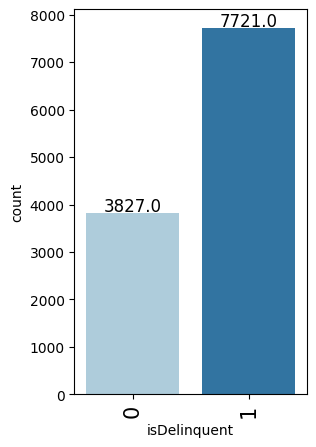

In [28]:
labeled_barplot(loan, 'isDelinquent')

### Observations on term

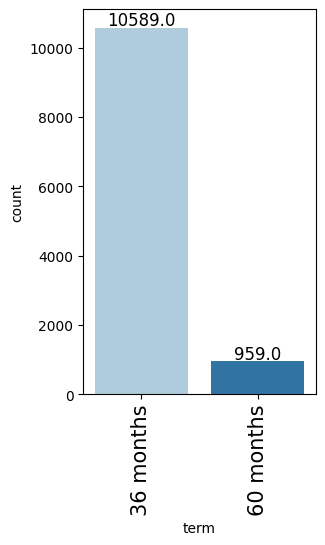

In [29]:
labeled_barplot(loan,'term')

### Observations on gender

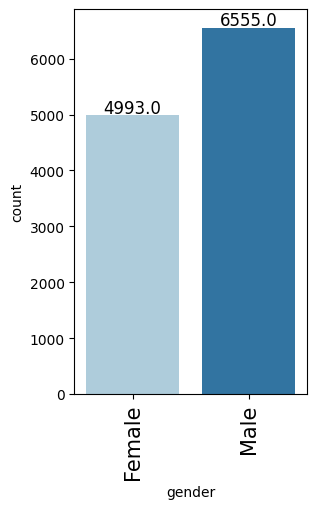

In [30]:
labeled_barplot(loan, 'gender')

### Observations on purpose

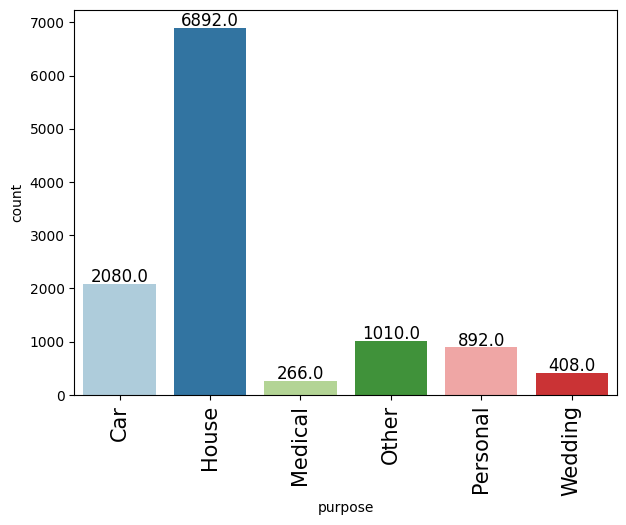

In [31]:
labeled_barplot(loan, 'purpose')

### Observations on home_ownership

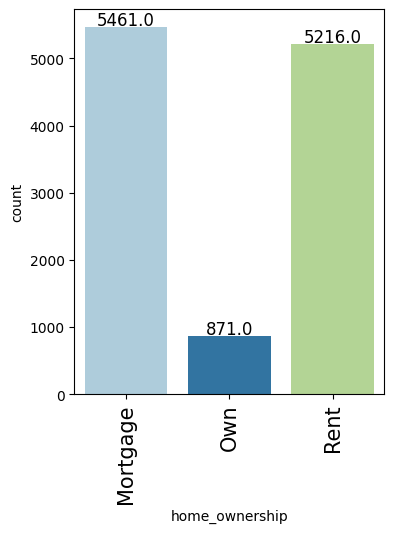

In [32]:
labeled_barplot(loan, 'home_ownership')

### Observations on age

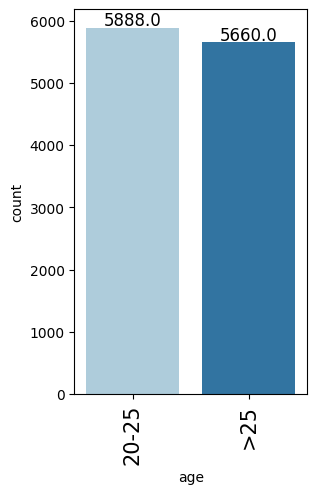

In [33]:
labeled_barplot(loan, 'age')

### Observations on FICO

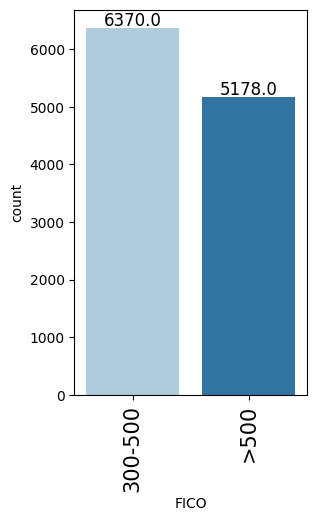

In [34]:
labeled_barplot(loan, 'FICO')

In [35]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

### Observations on term vs isDelinquent

isDelinquent     0     1    All
term                           
All           3827  7721  11548
36 months     3168  7421  10589
60 months      659   300    959
------------------------------------------------------------------------------------------------------------------------


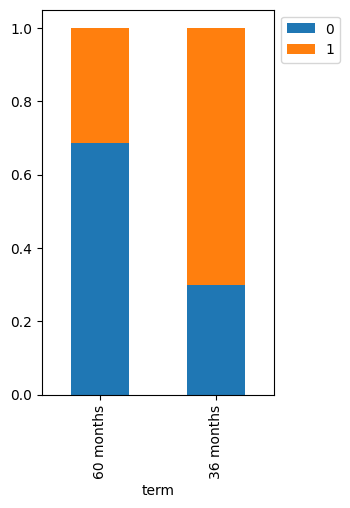

In [36]:
stacked_barplot(loan, 'term', 'isDelinquent')

### Observations on gender vs IsDelinquent

isDelinquent     0     1    All
gender                         
All           3827  7721  11548
Male          1977  4578   6555
Female        1850  3143   4993
------------------------------------------------------------------------------------------------------------------------


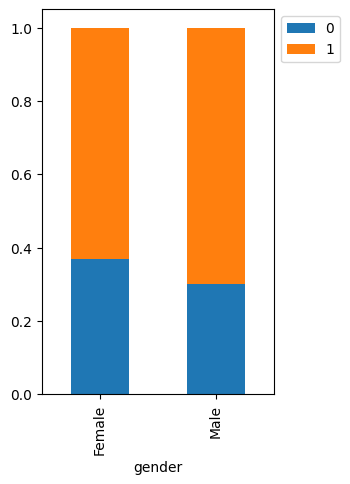

In [37]:
stacked_barplot(loan, 'gender','isDelinquent')

### Observations on purpose vs isDelinquent

isDelinquent     0     1    All
purpose                        
All           3827  7721  11548
House         2272  4620   6892
Car            678  1402   2080
Other          357   653   1010
Personal       274   618    892
Wedding        139   269    408
Medical        107   159    266
------------------------------------------------------------------------------------------------------------------------


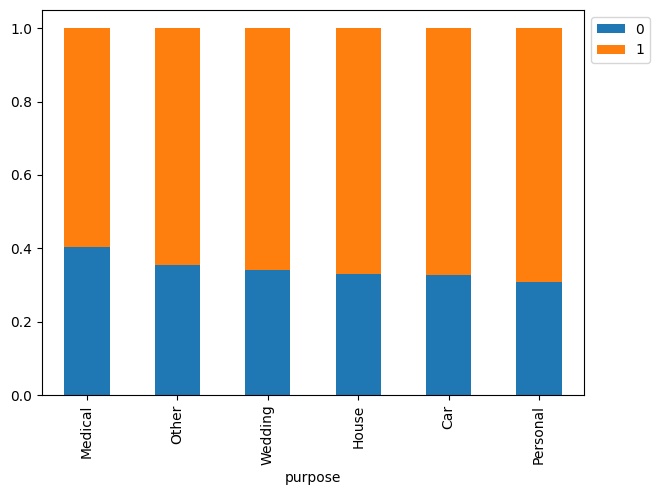

In [38]:
stacked_barplot(loan,'purpose','isDelinquent')

### Observations on home_ownership vs isDelinquent

isDelinquent       0     1    All
home_ownership                   
All             3827  7721  11548
Mortgage        1831  3630   5461
Rent            1737  3479   5216
Own              259   612    871
------------------------------------------------------------------------------------------------------------------------


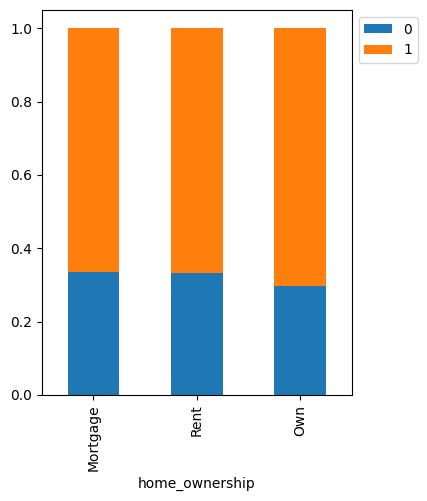

In [39]:
stacked_barplot(loan, 'home_ownership','isDelinquent')

### Observations on age vs isDelinquent

isDelinquent     0     1    All
age                            
All           3827  7721  11548
>25           1969  3691   5660
20-25         1858  4030   5888
------------------------------------------------------------------------------------------------------------------------


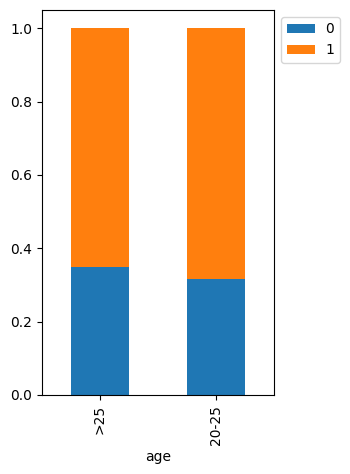

In [40]:
stacked_barplot(loan, 'age','isDelinquent')

### Observations on FICO vs isDelinquent

isDelinquent     0     1    All
FICO                           
All           3827  7721  11548
>500          2886  2292   5178
300-500        941  5429   6370
------------------------------------------------------------------------------------------------------------------------


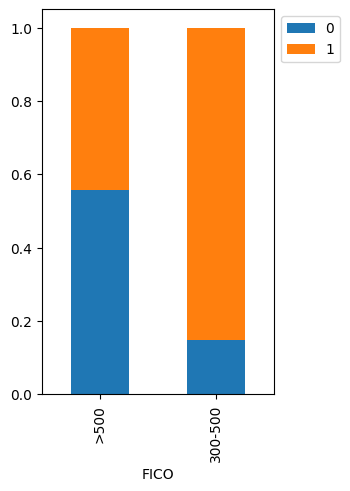

In [41]:
stacked_barplot(loan,'FICO','isDelinquent')

### Observations on home_ownership vs FICO

FICO            300-500  >500    All
home_ownership                      
All                6370  5178  11548
Mortgage           2857  2604   5461
Rent               3033  2183   5216
Own                 480   391    871
------------------------------------------------------------------------------------------------------------------------


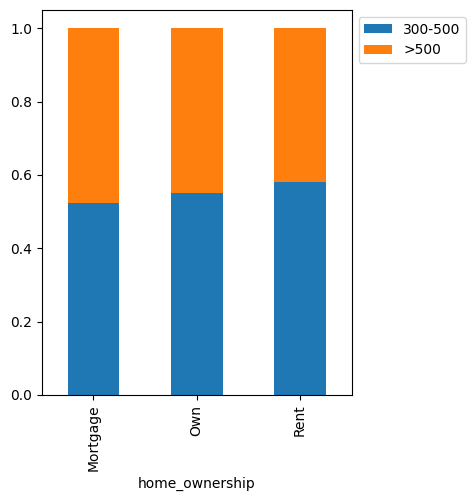

In [42]:
stacked_barplot(loan,'home_ownership','FICO')

### Observations on age vs FICO

FICO   300-500  >500    All
age                        
All       6370  5178  11548
>25       2443  3217   5660
20-25     3927  1961   5888
------------------------------------------------------------------------------------------------------------------------


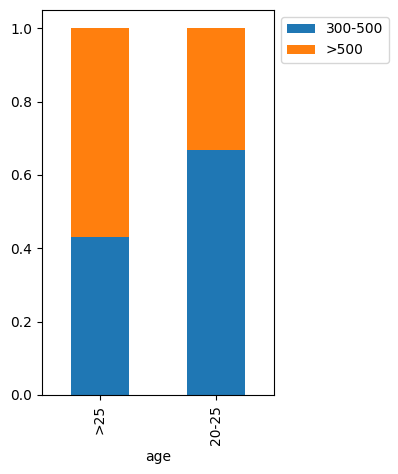

In [43]:
stacked_barplot(loan,'age','FICO')

### Observations on gender vs FICO

FICO    300-500  >500    All
gender                      
All        6370  5178  11548
Male       3705  2850   6555
Female     2665  2328   4993
------------------------------------------------------------------------------------------------------------------------


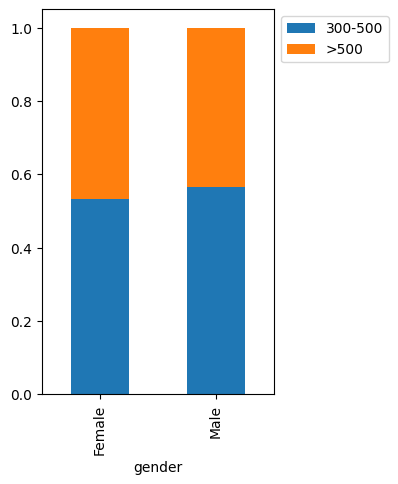

In [44]:
stacked_barplot(loan, 'gender','FICO')

### Let us check which of these differences are statistically significant.

The Chi-Square test is a statistical method to determine if two categorical variables have a significant correlation between them.
  
**Null Hypothesis -** There is no association between the two variables.      
**Alternate Hypothesis -** There is an association between two variables.

In [52]:
crosstab = pd.crosstab(loan['FICO'], loan['home_ownership'])
Ho = 'FICO score has no effect on home ownership' # Null hypothesis
Ha = 'FICO score has an effect on home ownership' # Alternative hypothesis
chi, p_value, dof, expected = stats.chi2_contingency(crosstab)
if p_value < 0.05:
    print(f'{Ha} as the p_value ({p_value.round(4):.4f}) < 0.05')
else:
    print(f'{Ho} as the p_value ({p_value.round(3):.4f}) > 0.05')

FICO score has an effect on home ownership as the p_value (0.0000) < 0.05


In [53]:
crosstab = pd.crosstab(loan['FICO'], loan['gender'])
Ho = 'FICO score has no effect on gender' # Null hypothesis
Ha = 'FICO score has an effect on gender' # Alternative hypothesis
chi, p_value, dof, expected = stats.chi2_contingency(crosstab)
if p_value < 0.05:
    print(f'{Ha} as the p_value ({p_value.round(4):.4f}) < 0.05')
else:
    print(f'{Ho} as the p_value ({p_value.round(3):.4f}) > 0.05')

FICO score has an effect on gender as the p_value (0.0008) < 0.05


In [55]:
crosstab = pd.crosstab(loan['FICO'],loan['age'])
Ho = 'FICO score has no effect on age' # Null hypothesis
Ha = 'FICO score has an effect on age' # Alternative hypothesis
chi, p_value, dof, expected = stats.chi2_contingency(crosstab)
if p_value < 0.5:
    print(f'{Ha} as the p_value ({p_value.round(4):.4f}) < 0.05')
else:
    print(f'{Ho} as the p_value ({p_value.round(4):.4f}) > 0.05')

FICO score has an effect on age as the p_value (0.0000) < 0.05


## Key Observations

* P-value for all tests < 0.01. Hence, all the differences that we see in the 3 plots are statistically significant.
* There is a correlation between FICO Score and house_ownership. People who have mortgaged their houses have higher FICO scores than people who own the house (peculiar!).
* There is a correlation between FICO Score and gender. More females have >500 FICO scores as compared to Males.
* There is a correlation between FICO Score and age. People >25 years of age have higher FICO scores as compared to people of age 20-25. 

### Data Preparation for Modeling

In [109]:
X = loan.drop(['isDelinquent'], axis=1)
y = loan['isDelinquent']

In [110]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11548 entries, 0 to 11547
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   term            11548 non-null  category
 1   gender          11548 non-null  category
 2   purpose         11548 non-null  category
 3   home_ownership  11548 non-null  category
 4   age             11548 non-null  category
 5   FICO            11548 non-null  category
dtypes: category(6)
memory usage: 68.6 KB


In [111]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,term_60 months,gender_Male,purpose_House,purpose_Medical,purpose_Other,purpose_Personal,purpose_Wedding,home_ownership_Own,home_ownership_Rent,age_>25,FICO_>500
0,False,False,True,False,False,False,False,False,False,True,False
1,False,False,True,False,False,False,False,False,True,False,True
2,False,False,True,False,False,False,False,False,True,True,False
3,False,False,False,False,False,False,False,False,False,True,False
4,False,False,True,False,False,False,False,False,True,True,False


In [112]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11548 entries, 0 to 11547
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   term_60 months       11548 non-null  bool 
 1   gender_Male          11548 non-null  bool 
 2   purpose_House        11548 non-null  bool 
 3   purpose_Medical      11548 non-null  bool 
 4   purpose_Other        11548 non-null  bool 
 5   purpose_Personal     11548 non-null  bool 
 6   purpose_Wedding      11548 non-null  bool 
 7   home_ownership_Own   11548 non-null  bool 
 8   home_ownership_Rent  11548 non-null  bool 
 9   age_>25              11548 non-null  bool 
 10  FICO_>500            11548 non-null  bool 
dtypes: bool(11)
memory usage: 124.2 KB


In [115]:
X = X.astype('uint8')

In [116]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11548 entries, 0 to 11547
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   term_60 months       11548 non-null  uint8
 1   gender_Male          11548 non-null  uint8
 2   purpose_House        11548 non-null  uint8
 3   purpose_Medical      11548 non-null  uint8
 4   purpose_Other        11548 non-null  uint8
 5   purpose_Personal     11548 non-null  uint8
 6   purpose_Wedding      11548 non-null  uint8
 7   home_ownership_Own   11548 non-null  uint8
 8   home_ownership_Rent  11548 non-null  uint8
 9   age_>25              11548 non-null  uint8
 10  FICO_>500            11548 non-null  uint8
dtypes: uint8(11)
memory usage: 124.2 KB


In [117]:
(X_temp, X_test,
 y_temp, y_test) = train_test_split(X,
                                    y,
                                    test_size=0.2,
                                    random_state=1,
                                    stratify=y)

(X_train, X_val,
 y_train, y_val) = train_test_split(X_temp,
                                    y_temp,
                                    test_size=0.25,
                                    random_state=1,
                                    stratify=y_temp)

print(X_train.shape, X_val.shape, X_test.shape)

(6928, 11) (2310, 11) (2310, 11)


In [118]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in validation data =", X_val.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 6928
Number of rows in validation data = 2310
Number of rows in test data = 2310


### Building the model

### Model evaluation criterion:

**What does a bank want?**
* A bank wants to minimize the loss - it can face 2 types of losses here: 
   * Whenever a bank lends money to a customer, they don't return that.
   * A bank doesn't lend money to a customer thinking a customer will default but in reality, the customer won't - opportunity loss.

**Which loss is greater ?**
* Lending to a customer who wouldn't be able to pay back.

**Since we want to reduce loan delinquency we should use Recall as a metric of model evaluation instead of accuracy.**

* Recall - It gives the ratio of True positives to Actual positives, so high Recall implies low false negatives, i.e. low chances of predicting loan-delinquent customers as a non-loan-delinquent customer.

In [119]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [120]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Logistic Regression

In [121]:
lr = LogisticRegression(random_state=1)
lr.fit(X_train, y_train)

LogisticRegression(random_state=1)

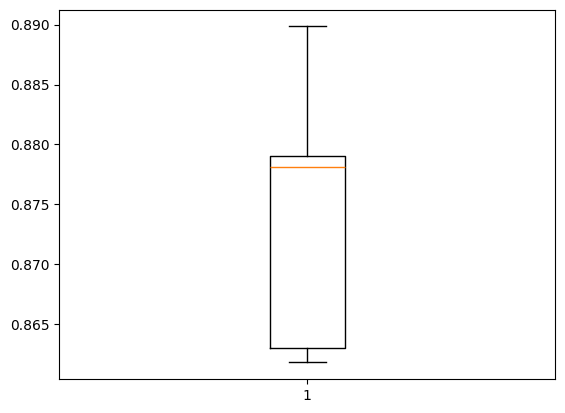

In [122]:
scoring='recall'
kfold = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=1)

cv_result_bfr = cross_val_score(
    estimator=lr, X=X_train, y=y_train, scoring=scoring, cv=kfold)

plt.boxplot(cv_result_bfr)
plt.show()

* Performance on training set varies between 0.86 to 0.87 recall.
* Let's check the performance on validation data.

In [123]:
# Calculating different metrics on train set
log_reg_model_train_perf = model_performance_classification_sklearn(
    lr, 
    X_train, 
    y_train
)
print("Training performance:")
log_reg_model_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.782621,0.872409,0.815375,0.842929


In [124]:
# Calculating different metrics on validation set
log_reg_model_val_perf = model_performance_classification_sklearn(lr,
                                                                  X_val, 
                                                                  y_val)
print("Validation performance:")
log_reg_model_val_perf

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.797403,0.891909,0.820727,0.854839


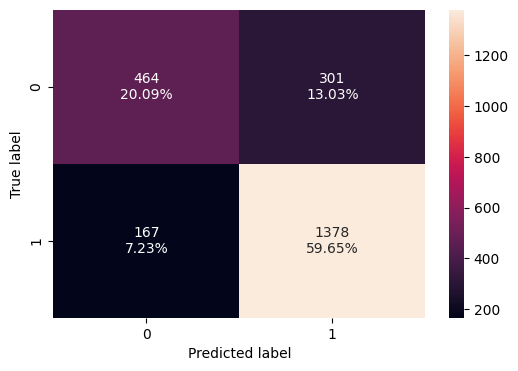

In [125]:
confusion_matrix_sklearn(lr, X_val, y_val)

### Oversampling train data using SMOTE

In [130]:
# Before oversampling
print("Before UpSampling, counts of label 'Yes': {}".format(
    sum(y_train==1)))
print("Before UpSampling, counts of label 'No': {}\n".format(
    sum(y_train==0)))

# perform oversampling using SMOTE
sm = SMOTE(sampling_strategy=1, 
           k_neighbors=5, 
           random_state=1)
# fit the SMOTE model to the X_train and y_train data
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


# After oversampling
print("After UpSampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After UpSampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After UpSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After UpSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before UpSampling, counts of label 'Yes': 4632
Before UpSampling, counts of label 'No': 2296

After UpSampling, counts of label 'Yes': 4632
After UpSampling, counts of label 'No': 4632 

After UpSampling, the shape of train_X: (9264, 11)
After UpSampling, the shape of train_y: (9264,) 



### Logistic Regression on oversampled data

In [131]:
log_reg_over = LogisticRegression(random_state=1)

# Training the basic logistic regression model with training set
log_reg_over.fit(X_train_over, y_train_over)

LogisticRegression(random_state=1)

#### Model Evaulation

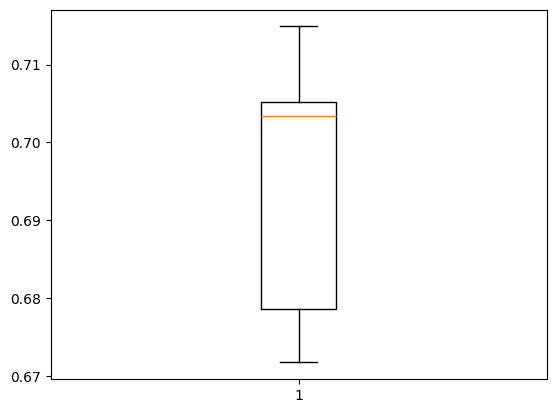

In [132]:
scoring = "recall"
kfold = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=1
)  # Setting number of splits equal to 5
cv_result_over = cross_val_score(
    estimator=log_reg_over, X=X_train_over, y=y_train_over, scoring=scoring, cv=kfold
)
# Plotting boxplots for CV scores of model defined above
plt.boxplot(cv_result_over)
plt.show()

* Performance on training set varies between 0.68 to 0.70 recall
* Let's check the performance on Validation set

In [133]:
# Calculating different metrics on train set
log_reg_over_train_perf = model_performance_classification_sklearn(
    log_reg_over, X_train_over, y_train_over
)
print("Training performance:")
log_reg_over_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.770078,0.694732,0.817997,0.751343


In [134]:
# Calculating different metrics on validation set
log_reg_over_val_perf = model_performance_classification_sklearn(
    log_reg_over, X_val, y_val
)
print("validation performance:")
log_reg_over_val_perf

validation performance:


,Accuracy,Recall,Precision,F1
0,0.760606,0.719094,0.903252,0.800721


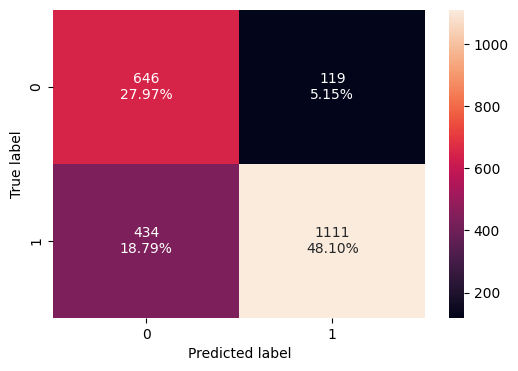

In [135]:
# creating confusion matrix
confusion_matrix_sklearn(log_reg_over, X_val, y_val)

### Regularization

In [137]:
lr_estimator = LogisticRegression(random_state=1,
                                  solver='saga')

parameters = {'C': np.arange(0.1, 1.1, 0.1)}

grid_obj = GridSearchCV(lr_estimator,
                        parameters,
                        scoring='recall').fit(X_train_over,
                                              y_train_over)
lr_estimator = grid_obj.best_estimator_
lr_estimator.fit(X_train_over, y_train_over)

LogisticRegression(C=0.1, random_state=1, solver='saga')

In [138]:
# Calculating different metrics on train set
log_reg_reg_train_perf = model_performance_classification_sklearn(
    lr_estimator, X_train_over, y_train_over
)
print("Training performance:")
log_reg_reg_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.721287,0.694732,0.733698,0.713684


In [139]:
# Calculating different metrics on validation set
log_reg_reg_val_perf = model_performance_classification_sklearn(
    lr_estimator, X_val, y_val
)
print("Validation performance:")
log_reg_reg_val_perf

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.737229,0.719094,0.865265,0.785437


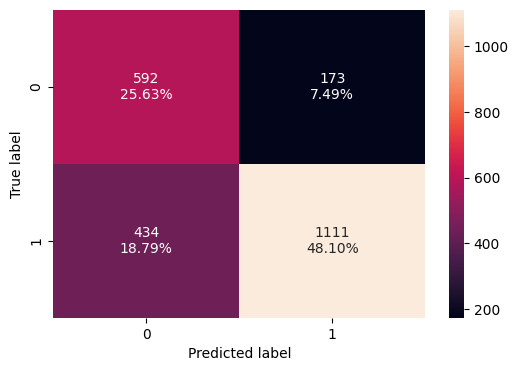

In [140]:
# creating confusion matrix
confusion_matrix_sklearn(lr_estimator, X_val, y_val)

* Recall is good but not much different from previous model

### Undersampling train data using RandomUnderSampler

In [141]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [143]:
#Before under samplint
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))


# After under sampling
print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 4632
Before Under Sampling, counts of label 'No': 2296 

After Under Sampling, counts of label 'Yes': 2296
After Under Sampling, counts of label 'No': 2296 

After Under Sampling, the shape of train_X: (4592, 11)
After Under Sampling, the shape of train_y: (4592,) 



### Logistic Regression on undersampled data

In [144]:
log_reg_under = LogisticRegression(random_state=1).fit(X_train_un,
                                                       y_train_un)

### Evaluate the model

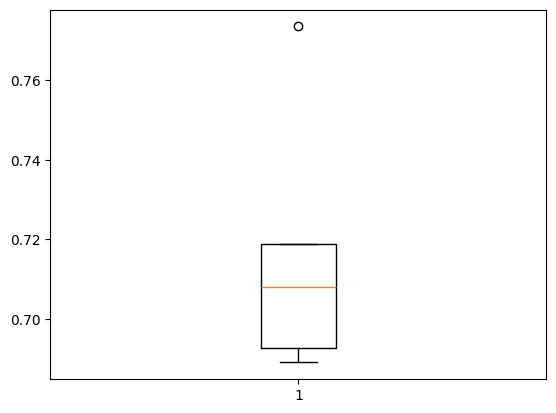

In [145]:
scoring = "recall"
kfold = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=1
)  # Setting number of splits equal to 5
cv_result_under = cross_val_score(
    estimator=log_reg_under, X=X_train_un, y=y_train_un, scoring=scoring, cv=kfold
)
# Plotting boxplots for CV scores of model defined above
plt.boxplot(cv_result_under)
plt.show()

* Performance of model on training set varies between 0.70 to 0.72, which is similar to model with oversampled data
* Let's check the performance on the validation set.

In [149]:
# Calculating different metrics on train set
log_reg_under_train_perf = model_performance_classification_sklearn(
    log_reg_under, 
    X_train_un, 
    y_train_un
)
print("Training performance:")
log_reg_under_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.768075,0.708624,0.804251,0.753415


In [150]:
# Calculating different metrics on validation set
log_reg_under_val_perf = model_performance_classification_sklearn(
    log_reg_under, 
    X_val, 
    y_val
)
print("Validation performance:")
log_reg_under_val_perf

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.769264,0.739806,0.897174,0.810926


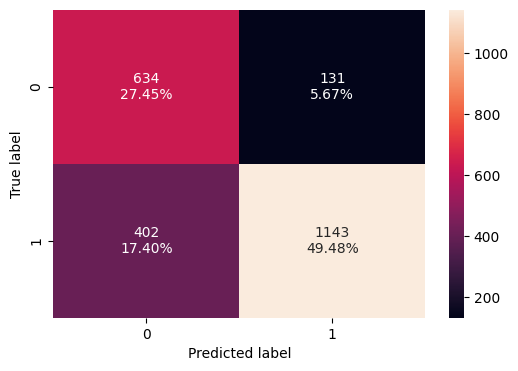

In [151]:
confusion_matrix_sklearn(log_reg_under, X_val, y_val)

* Model has given a generalized performance on training and validation set.
* Model performance has improved using downsampling - Logistic regression is now able to differentiate well between positive and negative classes.

In [152]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        log_reg_model_train_perf.T,
        log_reg_over_train_perf.T,
        log_reg_reg_train_perf.T,
        log_reg_under_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression",
    "Logistic Regression with oversampled data",
    "Regularised Logistic Regression",
    "Logistic Regression with undersampled data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Regression,Logistic Regression with oversampled data,Regularised Logistic Regression,Logistic Regression with undersampled data
Accuracy,0.782621,0.770078,0.721287,0.768075
Recall,0.872409,0.694732,0.694732,0.708624
Precision,0.815375,0.817997,0.733698,0.804251
F1,0.842929,0.751343,0.713684,0.753415


In [153]:
# Validation performance comparison

models_train_comp_df = pd.concat(
    [
        log_reg_model_val_perf.T,
        log_reg_over_val_perf.T,
        log_reg_reg_val_perf.T,
        log_reg_under_val_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression",
    "Logistic Regression with oversampled data",
    "Regularised Logistic Regression",
    "Logistic Regression with undersampled data",
]
print("Validation performance comparison:")
models_train_comp_df

Validation performance comparison:


,Logistic Regression,Logistic Regression with oversampled data,Regularised Logistic Regression,Logistic Regression with undersampled data
Accuracy,0.797403,0.760606,0.737229,0.769264
Recall,0.891909,0.719094,0.719094,0.739806
Precision,0.820727,0.903252,0.865265,0.897174
F1,0.854839,0.800721,0.785437,0.810926


* The first model has the best recall value

### Evaluate perform of 1st model on test data

In [154]:
# Calculating different metrics on validation set
log_reg_model_test_perf = model_performance_classification_sklearn(
    log_reg_under, X_test, y_test
)
print("Test performance:")
log_reg_model_test_perf

Test performance:


,Accuracy,Recall,Precision,F1
0,0.765368,0.733808,0.896361,0.80698


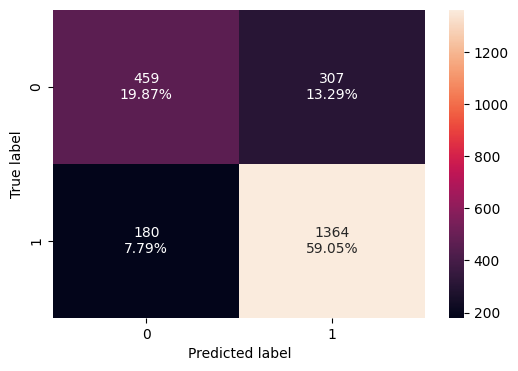

In [155]:
# creating confusion matrix
confusion_matrix_sklearn(lr, X_test, y_test)

### Retrieve the coefficients of the logistic model

In [156]:
coed_df = pd.DataFrame(
    np.append(lr.coef_, lr.intercept_), # include intercept value
    index=X_train.columns.tolist() +['Intercept'], # include intercept column
    columns=['Coefficients'])
coed_df.T

,term_60 months,gender_Male,purpose_House,purpose_Medical,purpose_Other,purpose_Personal,purpose_Wedding,home_ownership_Own,home_ownership_Rent,age_>25,FICO_>500,Intercept
Coefficients,-2.033788,0.790446,0.086187,0.409481,-0.050275,0.171595,0.044048,0.103589,-0.089995,0.563389,-1.981912,1.165601


### Convert the coefficients to odds

In [157]:
odds = np.exp(lr.coef_[0])
pd.DataFrame(
    odds, X_train.columns, columns=['odds']).T


,term_60 months,gender_Male,purpose_House,purpose_Medical,purpose_Other,purpose_Personal,purpose_Wedding,home_ownership_Own,home_ownership_Rent,age_>25,FICO_>500
odds,0.130839,2.204379,1.09001,1.506036,0.950968,1.187197,1.045032,1.109145,0.913936,1.756616,0.137805


### Convert the coefficients to percentage changes

In [160]:
perc_change_odds = (np.exp(lr.coef_[0]) - 1) * 100
pd.DataFrame(
    perc_change_odds, X_train.columns, columns=['Change odd %']).T

,term_60 months,gender_Male,purpose_House,purpose_Medical,purpose_Other,purpose_Personal,purpose_Wedding,home_ownership_Own,home_ownership_Rent,age_>25,FICO_>500
Change odd %,-86.916105,120.437917,9.001019,50.603603,-4.903246,18.719705,4.503241,10.914457,-8.60642,75.661593,-86.219456
